# Logistic Regression with Neural Network Mindset - Code Examples
## Week 2 Part 3 - Hands-on Implementation

#### Sections:
1. Sigmoid Function & Logistic Regression Basics
2. Cost Function Implementation (Cross-Entropy)
3. Gradient Descent from Scratch
4. Forward & Backward Propagation
5. Complete Cat vs Non-Cat Classifier
6. Performance Analysis & Optimization

## 1. Sigmoid Function & Logistic Regression Basics

In [13]:
%pip install numpy
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [14]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    """
    Compute the sigmoid of z
    Arguments: z -- a scalar or numpy array of any size
    Returns: s -- sigmoid(z)
    """
    s = 1/(1+np.exp(-z))
    return s

# Test the sigmoid function with a single number
z = -10
print("z= ",z)
print("sigmoid(z) = ", sigmoid(z))

print("\n")

# Test the sigmoid function with array
z_arr = np.array([-10, -5, 0, 5, 10])
print("z_arr= ",z_arr)
print("sigmoid(z_arr) = ", sigmoid(z_arr))

z=  -10
sigmoid(z) =  4.5397868702434395e-05


z_arr=  [-10  -5   0   5  10]
sigmoid(z_arr) =  [4.53978687e-05 6.69285092e-03 5.00000000e-01 9.93307149e-01
 9.99954602e-01]


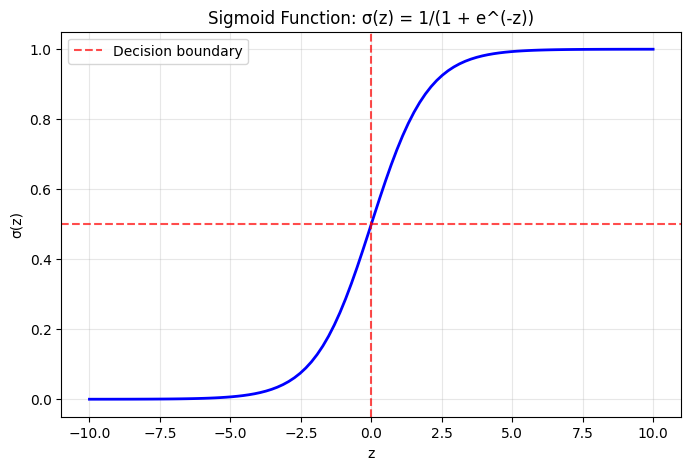

In [15]:
# Visualize sigmoid function
z_range = np.linspace(-10, 10, 100)
sigmoid_values = sigmoid(z_range)

plt.figure(figsize=(8, 5))
plt.plot(z_range, sigmoid_values, 'b-', linewidth=2)
plt.title('Sigmoid Function: σ(z) = 1/(1 + e^(-z))')
plt.xlabel('z')
plt.ylabel('σ(z)')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.7, label='Decision boundary')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## 2.Cost Function Implementation (Cross-Entropy)

#### Loss function

In [16]:
def compute_loss(y_pred, y_true):
    """
    Computes the logistic loss for a single example
    Loss Function: L(y',y) = -(y*log(y') + (1-y)*log(1-y'))

    Args:
        y_pred : predicted probability (scalar)
        y_true : true label (0 or 1, scalar)
    Returns:
        loss : logistic loss for single example
    """

    # Add small epsilon to prevent log(0)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1-epsilon)

    loss = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

#### Compute cost with compute loss function

In [17]:
def compute_cost_with_loss_function(A,Y):
    """
        Computes the cost function by averaging the loss over ALL examples
        Cost Function: J(w,b) = (1/m) * Sum(L(y'[i], y[i]))
        
        Arguments:
        A -- The sigmoid output of shape (1, number of examples)
        Y -- "true" labels vector of shape (1, number of examples)
        Returns:
        cost -- average cross-entropy cost across all examples
    """

    # number of examples
    m = Y.shape[1]

    # computing loss using the loss function (for educational purposes)
    total_loss = 0
    for i in range(m):
        loss_i = compute_loss(A[0,i], Y[0,i])
        total_loss += loss_i

    # Calculate the average cost
    cost = total_loss/m

    # Make sure cost is the dimension we expect
    cost = np.squeeze(cost)

    return cost


In [18]:
# Test both loss and cost functions
A = np.array([[0.8, 0.9, 0.4]])  # predictions
Y = np.array([[1, 1, 0]])        # true labels

# Test individual loss function
print("=== Testing Loss Function (Single Examples) ===")
loss_1 = compute_loss(0.8, 1)  # correct prediction
loss_2 = compute_loss(0.9, 1)  # very correct prediction  
loss_3 = compute_loss(0.4, 0)  # correct prediction
print(f"Loss for prediction=0.8, true=1: {loss_1:.4f}")
print(f"Loss for prediction=0.9, true=1: {loss_2:.4f}")
print(f"Loss for prediction=0.4, true=0: {loss_3:.4f}")

# Test cost function (average of all losses)
cost = compute_cost_with_loss_function(A, Y)
print(f"\n=== Testing Cost Function (Average of All) ===")
print(f"Cost (average loss) = {cost:.4f}")

# Manual verification: average of individual losses
manual_cost = (loss_1 + loss_2 + loss_3) / 3
print(f"Manual calculation: ({loss_1:.4f} + {loss_2:.4f} + {loss_3:.4f}) / 3 = {manual_cost:.4f}")
print(f"Match: {np.isclose(cost, manual_cost)}")


=== Testing Loss Function (Single Examples) ===
Loss for prediction=0.8, true=1: 0.2231
Loss for prediction=0.9, true=1: 0.1054
Loss for prediction=0.4, true=0: 0.5108

=== Testing Cost Function (Average of All) ===
Cost (average loss) = 0.2798
Manual calculation: (0.2231 + 0.1054 + 0.5108) / 3 = 0.2798
Match: True


#### compute cost vectorized approach (faster)

In [19]:
def compute_cost(A,Y):
    """
        Computes the cost function by averaging the loss over ALL examples
        Cost Function: J(w,b) = (1/m) * Sum(L(y'[i], y[i]))
        
        Arguments:
        A -- The sigmoid output of shape (1, number of examples)
        Y -- "true" labels vector of shape (1, number of examples)
        Returns:
        cost -- average cross-entropy cost across all examples
    """

    # number of examples
    m = Y.shape[1]

    logprobs = np.multiply(Y,np.log(A)) + np.multiply((1-Y), np.log(1-A))
    cost = -np.sum(logprobs) / m

    cost = np.squeeze(cost)
    return cost

In [20]:
# Test both loss and cost functions
A = np.array([[0.8, 0.9, 0.4]])  # predictions
Y = np.array([[1, 1, 0]])        # true labels

# Test individual loss function
print("=== Testing Loss Function (Single Examples) ===")
loss_1 = compute_loss(0.8, 1)  # correct prediction
loss_2 = compute_loss(0.9, 1)  # very correct prediction  
loss_3 = compute_loss(0.4, 0)  # correct prediction
print(f"Loss for prediction=0.8, true=1: {loss_1:.4f}")
print(f"Loss for prediction=0.9, true=1: {loss_2:.4f}")
print(f"Loss for prediction=0.4, true=0: {loss_3:.4f}")

# Test cost function (average of all losses)
cost = compute_cost(A, Y)
print(f"\n=== Testing Cost Function (Average of All) ===")
print(f"Cost (average loss) = {cost:.4f}")

# Manual verification: average of individual losses
manual_cost = (loss_1 + loss_2 + loss_3) / 3
print(f"Manual calculation: ({loss_1:.4f} + {loss_2:.4f} + {loss_3:.4f}) / 3 = {manual_cost:.4f}")
print(f"Match: {np.isclose(cost, manual_cost)}")

=== Testing Loss Function (Single Examples) ===
Loss for prediction=0.8, true=1: 0.2231
Loss for prediction=0.9, true=1: 0.1054
Loss for prediction=0.4, true=0: 0.5108

=== Testing Cost Function (Average of All) ===
Cost (average loss) = 0.2798
Manual calculation: (0.2231 + 0.1054 + 0.5108) / 3 = 0.2798
Match: True


#### Visualize how cost changes with predictions

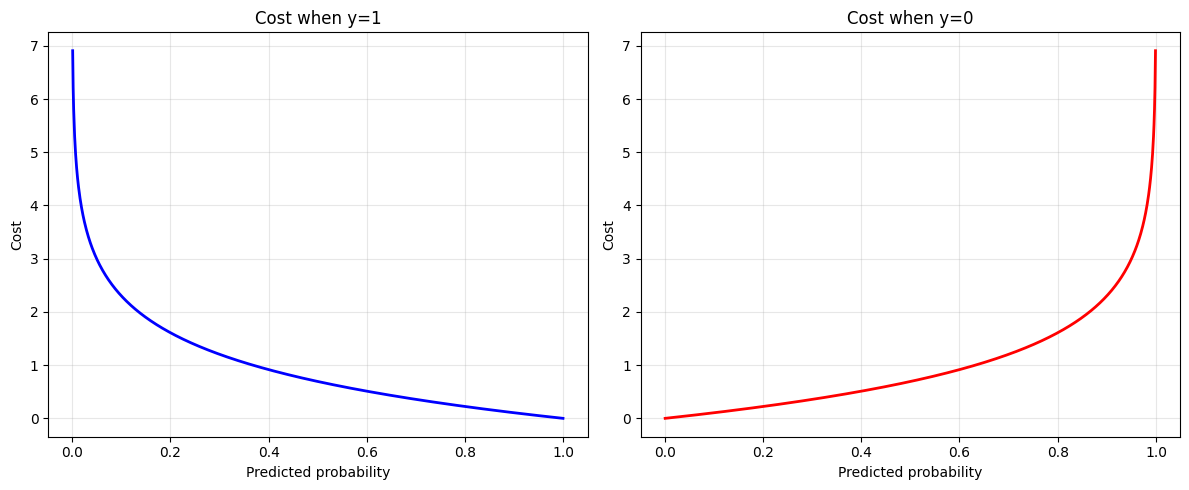

In [21]:
predictions = np.linspace(0.001, 0.999, 1000)
costs_y1 = [compute_loss(p, 1) for p in predictions]      # when y=1
costs_y0 = [compute_loss(p, 0) for p in predictions]      # when y=0

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(predictions, costs_y1, 'b-', linewidth=2)
plt.title('Cost when y=1')
plt.xlabel('Predicted probability')
plt.ylabel('Cost')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(predictions, costs_y0, 'r-', linewidth=2)
plt.title('Cost when y=0')
plt.xlabel('Predicted probability')
plt.ylabel('Cost')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3.Gradient Descent from Scratch

### 3.1 Mathematical Foundation: Understanding Derivatives

In [22]:
# First, let's understand what derivatives mean with a simple example
def f(x):
    return x**2

def df_dx(x):
    return 2*x

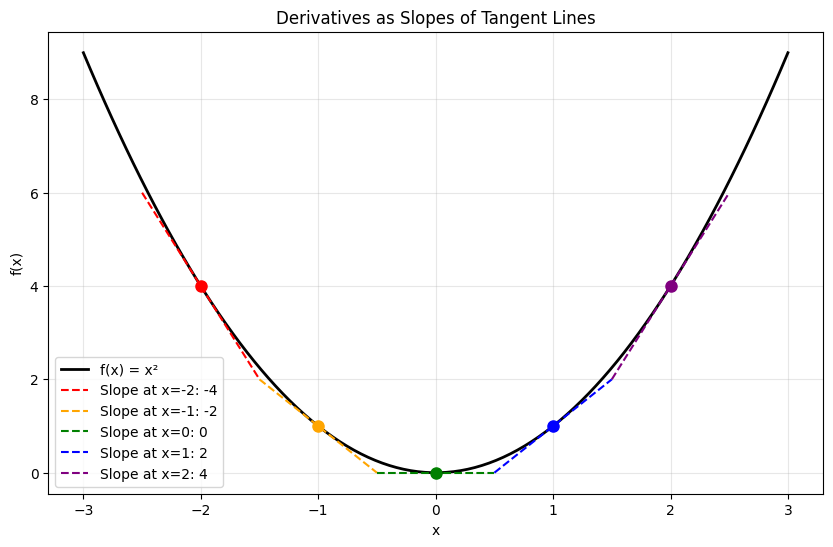

Key Insight: Derivative = Slope = Rate of Change
Positive slope → function increasing
Negative slope → function decreasing
Zero slope → local minimum/maximum


In [23]:
# Visualizing derivatives as slopes
x = np.linspace(-3, 3, 100)
y = f(x)

# Points to show tangent lines
points = [-2, -1, 0, 1, 2]
colors = ['red', 'orange', 'green', 'blue', 'purple']

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=2, label='f(x) = x²')

for i, point in enumerate(points):
    # Function value at point
    y_point = f(point)
    # Derivative (slope) at point
    slope = df_dx(point)

    # Tangent line
    x_tangent = np.linspace(point-0.5, point+0.5, 10)
    y_tangent = y_point + slope * (x_tangent - point)

    plt.plot(point, y_point, 'o', color=colors[i], markersize=8)
    plt.plot(x_tangent, y_tangent, '--', color=colors[i],
             label=f'Slope at x={point}: {slope}')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Derivatives as Slopes of Tangent Lines')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Key Insight: Derivative = Slope = Rate of Change")
print("Positive slope → function increasing")
print("Negative slope → function decreasing")
print("Zero slope → local minimum/maximum")


#### 3.2 Gradient Descent: Core Algorithm


=== Gradient Descent Core Algorithm ===
Update Rules:
w = w - α * (∂J/∂w)
b = b - α * (∂J/∂b)

Where:
α (alpha) = learning rate (how big steps to take)
∂J/∂w = partial derivative of cost with respect to w
∂J/∂b = partial derivative of cost with respect to b

=== 1D Gradient Descent Example ===
Goal: Find w that minimizes J(w) = (w-3)² + 1
Starting w: 0
Iteration 1: w=0.000, gradient=-6.000, new_w=0.600
Iteration 2: w=0.600, gradient=-4.800, new_w=1.080
Iteration 3: w=1.080, gradient=-3.840, new_w=1.464
Iteration 4: w=1.464, gradient=-3.072, new_w=1.771
Iteration 5: w=1.771, gradient=-2.458, new_w=2.017
Iteration 6: w=2.017, gradient=-1.966, new_w=2.214
Iteration 7: w=2.214, gradient=-1.573, new_w=2.371
Iteration 8: w=2.371, gradient=-1.258, new_w=2.497
Iteration 9: w=2.497, gradient=-1.007, new_w=2.597
Iteration 10: w=2.597, gradient=-0.805, new_w=2.678


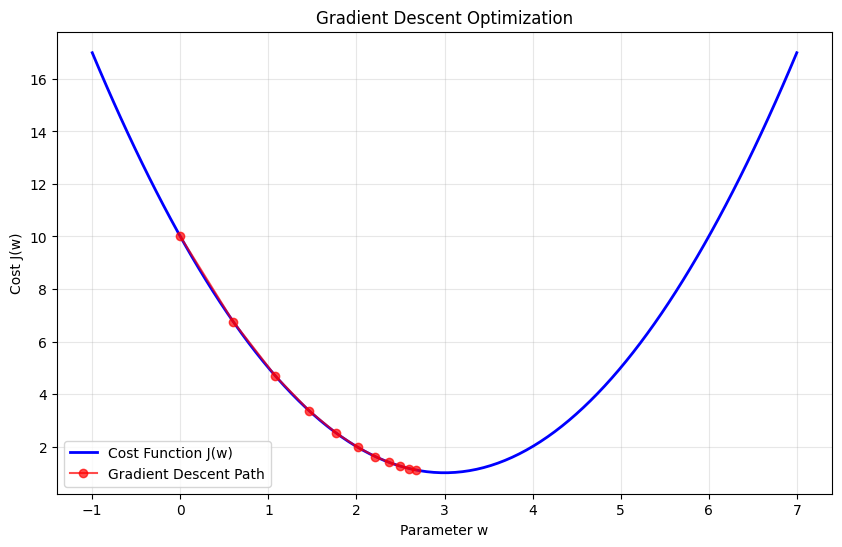

In [24]:
print("\n=== Gradient Descent Core Algorithm ===")
print("Update Rules:")
print("w = w - α * (∂J/∂w)")
print("b = b - α * (∂J/∂b)")
print("\nWhere:")
print("α (alpha) = learning rate (how big steps to take)")
print("∂J/∂w = partial derivative of cost with respect to w")
print("∂J/∂b = partial derivative of cost with respect to b")

# Define a simple quadratic cost function (REASON explained below)
def cost_function(w):
    return (w-3)**2 + 1

def gradient(w):
    return 2 * (w-3)

# Gradient descent simulation
w = 0   # Starting point
alpha = 0.1 #Learning rate
history = [w]

print(f"\n=== 1D Gradient Descent Example ===")
print(f"Goal: Find w that minimizes J(w) = (w-3)² + 1")
print(f"Starting w: {w}")

for i in range(10):
    grad = gradient(w)
    w_new = w - alpha * grad  # Update rule
    print(f"Iteration {i+1}: w={w:.3f}, gradient={grad:.3f}, new_w={w_new:.3f}")
    w = w_new
    history.append(w)

# Visualize the optimization path
w_range = np.linspace(-1, 7, 100)
cost_values = [cost_function(w) for w in w_range]

plt.figure(figsize=(10, 6))
plt.plot(w_range, cost_values, 'b-', linewidth=2, label='Cost Function J(w)')
plt.plot(history, [cost_function(w) for w in history], 'ro-', alpha=0.7, label='Gradient Descent Path')
plt.xlabel('Parameter w')
plt.ylabel('Cost J(w)')
plt.title('Gradient Descent Optimization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##### NOTE: Why This Function?
```python
def cost_function(w):
    return (w - 3)**2 + 1
```

This is chosen because it's:
1. **Simple to understand** - easy to visualize
2. **Has a clear minimum** - at w = 3
3. **Convex** - bowl-shaped, no local minima
4. **Similar to real ML** - quadratic like many cost functions

##### **How We Get the Gradient: Step by Step**

##### **Mathematical Derivation:**

```python
# Given function: f(w) = (w - 3)² + 1

# Step 1: Expand the function
f(w) = (w - 3)² + 1
f(w) = (w - 3) * (w - 3) + 1
f(w) = w² - 6w + 9 + 1
f(w) = w² - 6w + 10

# Step 2: Take the derivative using power rule
# d/dw[w²] = 2w
# d/dw[-6w] = -6  
# d/dw[10] = 0

df/dw = 2w - 6
df/dw = 2(w - 3)

# So gradient(w) = 2(w - 3)
```

##### **Alternative Method: Chain Rule**

```python
# f(w) = (w - 3)² + 1
# Let u = w - 3, then f = u² + 1

# Chain rule: df/dw = df/du * du/dw
# df/du = 2u
# du/dw = 1
# Therefore: df/dw = 2u * 1 = 2(w - 3)
```

##### Visual proof

=== Verifying the Gradient ===
w	f(w)	Gradient	Meaning
----------------------------------------
0	10.0	-6.0		→ go right (increase w)
1	5.0	-4.0		→ go right (increase w)
2	2.0	-2.0		→ go right (increase w)
3	1.0	+0.0		→ MINIMUM! stop here
4	2.0	+2.0		→ go left (decrease w)
5	5.0	+4.0		→ go left (decrease w)
6	10.0	+6.0		→ go left (decrease w)


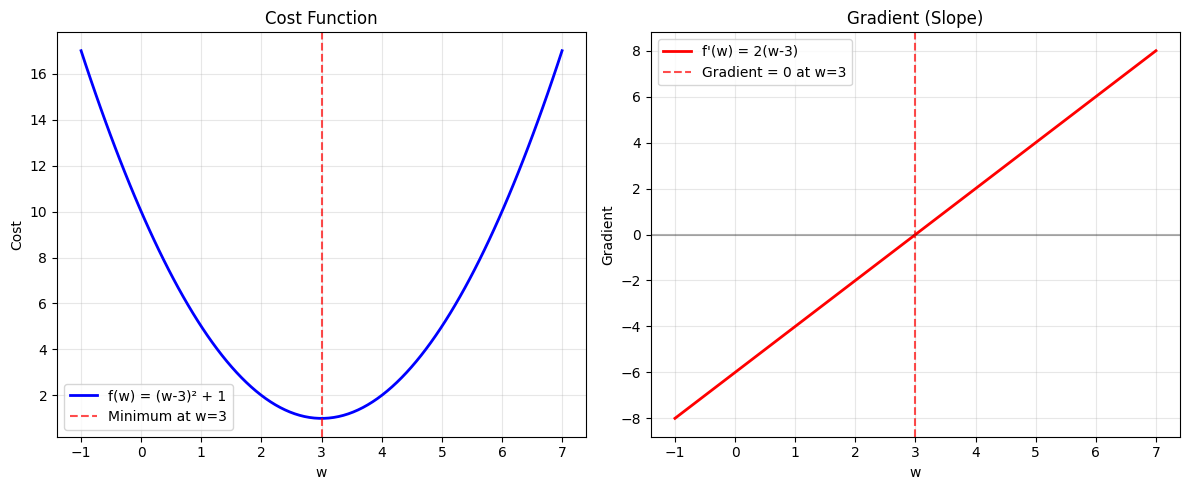

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def cost_function(w):
    return (w - 3)**2 + 1

def gradient(w):
    return 2 * (w - 3)

# Test points
w_values = np.array([0, 1, 2, 3, 4, 5, 6])

print("=== Verifying the Gradient ===")
print("w\tf(w)\tGradient\tMeaning")
print("-" * 40)

for w in w_values:
    cost = cost_function(w)
    grad = gradient(w)
    
    if grad > 0:
        direction = "→ go left (decrease w)"
    elif grad < 0:
        direction = "→ go right (increase w)"
    else:
        direction = "→ MINIMUM! stop here"
    
    print(f"{w}\t{cost:.1f}\t{grad:+.1f}\t\t{direction}")

# Visualize
w_range = np.linspace(-1, 7, 100)
cost_values = [cost_function(w) for w in w_range]
grad_values = [gradient(w) for w in w_range]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot cost function
ax1.plot(w_range, cost_values, 'b-', linewidth=2, label='f(w) = (w-3)² + 1')
ax1.axvline(x=3, color='r', linestyle='--', alpha=0.7, label='Minimum at w=3')
ax1.set_xlabel('w')
ax1.set_ylabel('Cost')
ax1.set_title('Cost Function')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot gradient
ax2.plot(w_range, grad_values, 'r-', linewidth=2, label="f'(w) = 2(w-3)")
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.axvline(x=3, color='r', linestyle='--', alpha=0.7, label='Gradient = 0 at w=3')
ax2.set_xlabel('w')
ax2.set_ylabel('Gradient')
ax2.set_title('Gradient (Slope)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### Why This Matters for Machine Learning:

In [26]:
print("\n=== Connection to Real ML ===")
print("This simple example teaches:")
print("1. Gradient = slope = direction to move")
print("2. Positive gradient → decrease parameter")
print("3. Negative gradient → increase parameter") 
print("4. Zero gradient → found minimum!")
print("5. Gradient descent: w_new = w_old - α * gradient")

# Show gradient descent in action
w = 0  # Start far from minimum
alpha = 0.1
history = [w]

print(f"\nGradient Descent Steps:")
print(f"Starting at w = {w}")

for i in range(8):
    grad = gradient(w)
    w_new = w - alpha * grad
    print(f"Step {i+1}: w={w:.3f}, gradient={grad:+.3f}, w_new={w_new:.3f}")
    w = w_new
    history.append(w)

print(f"Final w = {w:.3f} (target: 3.000)")


=== Connection to Real ML ===
This simple example teaches:
1. Gradient = slope = direction to move
2. Positive gradient → decrease parameter
3. Negative gradient → increase parameter
4. Zero gradient → found minimum!
5. Gradient descent: w_new = w_old - α * gradient

Gradient Descent Steps:
Starting at w = 0
Step 1: w=0.000, gradient=-6.000, w_new=0.600
Step 2: w=0.600, gradient=-4.800, w_new=1.080
Step 3: w=1.080, gradient=-3.840, w_new=1.464
Step 4: w=1.464, gradient=-3.072, w_new=1.771
Step 5: w=1.771, gradient=-2.458, w_new=2.017
Step 6: w=2.017, gradient=-1.966, w_new=2.214
Step 7: w=2.214, gradient=-1.573, w_new=2.371
Step 8: w=2.371, gradient=-1.258, w_new=2.497
Final w = 2.497 (target: 3.000)


##### **Key Insights:**

1.  **The function `(w-3)² + 1`** has its minimum at w=3
2.  **The gradient `2(w-3)`** tells us:
    -   When w < 3: gradient is negative → increase w
    -   When w > 3: gradient is positive → decrease w
    -   When w = 3: gradient is zero → stop (minimum found)
3.  **This is exactly how gradient descent works** in real ML!

The beauty is that this simple quadratic function behaves just like more complex cost functions in machine learning - the gradient always points toward the minimum! 🎯

#### 3.3 Chain Rule: Building Complex Derivatives

In [27]:
print("\n=== Chain Rule in Action ===")
print("Chain Rule: If x → y → z, then dz/dx = (dz/dy) × (dy/dx)")

# Example: J = (x + y) x z
x,y,z = 2,3,4
u = x + y   # u = 5
J = u * z    # J = 20

print("\nForward Pass:")
print(f"x={x}, y={y}, z={z}")
print(f"u = x + y = {u}")
print(f"J = u × z = {J}")


=== Chain Rule in Action ===
Chain Rule: If x → y → z, then dz/dx = (dz/dy) × (dy/dx)

Forward Pass:
x=2, y=3, z=4
u = x + y = 5
J = u × z = 20


##### Computation graph
```
x (2) ──┐
        ├─→ u (5) ──→ J (20)
y (3) ──┘           ↗
z (4) ──────────────┘
```

In [28]:
# Backward pass: compute derivatives
dJ_dJ = 1      # dJ/dJ = 1 (starting point)
dJ_du = z      # dJ/du = z = 4
dJ_dz = u      # dJ/dz = u = 5
dJ_dx = dJ_du * 1  # dJ/dx = (dJ/du) × (du/dx) = 4 × 1 = 4
dJ_dy = dJ_du * 1  # dJ/dy = (dJ/du) × (du/dy) = 4 × 1 = 4

print("\nBackward Pass (Derivatives):")
print(f"dJ/dx = {dJ_dx}")
print(f"dJ/dy = {dJ_dy}")
print(f"dJ/dz = {dJ_dz}")


Backward Pass (Derivatives):
dJ/dx = 4
dJ/dy = 4
dJ/dz = 5


#### Backward Pass: Computing Gradients Step by Step

##### Step 1: Start at the End

In [29]:
dJ_dJ = 1  # dJ/dJ = 1 (starting point)
print("Step 1: dJ/dJ = 1")
print("Why? The derivative of J with respect to itself is always 1")
print("Think: if J changes by 1, how much does J change? Obviously 1!")

Step 1: dJ/dJ = 1
Why? The derivative of J with respect to itself is always 1
Think: if J changes by 1, how much does J change? Obviously 1!


#### Step 2: How Does J Change with u?

In [30]:
# J = u × z, so dJ/du = z
dJ_du = z  # dJ/du = z = 4
print(f"\nStep 2: dJ/du = {dJ_du}")
print(f"Why? J = u × z = u × {z}")
print(f"If u increases by 1, J increases by {z}")
print(f"So dJ/du = {z}")


Step 2: dJ/du = 4
Why? J = u × z = u × 4
If u increases by 1, J increases by 4
So dJ/du = 4


#### Step 3: How Does J Change with z?

In [31]:
# J = u × z, so dJ/dz = u  
dJ_dz = u  # dJ/dz = u = 5
print(f"\nStep 3: dJ/dz = {dJ_dz}")
print(f"Why? J = u × z = {u} × z")
print(f"If z increases by 1, J increases by {u}")
print(f"So dJ/dz = {u}")


Step 3: dJ/dz = 5
Why? J = u × z = 5 × z
If z increases by 1, J increases by 5
So dJ/dz = 5


#### Step 4: How Does J Change with x? (Chain Rule!)

In [32]:
# Chain rule: dJ/dx = (dJ/du) × (du/dx)
du_dx = 1  # u = x + y, so du/dx = 1
dJ_dx = dJ_du * du_dx  # 4 × 1 = 4

print(f"\nStep 4: dJ/dx = (dJ/du) × (du/dx)")
print(f"dJ/du = {dJ_du} (from step 2)")
print(f"du/dx = {du_dx} (because u = x + y)")
print(f"dJ/dx = {dJ_du} × {du_dx} = {dJ_dx}")
print(f"Meaning: if x increases by 1, J increases by {dJ_dx}")


Step 4: dJ/dx = (dJ/du) × (du/dx)
dJ/du = 4 (from step 2)
du/dx = 1 (because u = x + y)
dJ/dx = 4 × 1 = 4
Meaning: if x increases by 1, J increases by 4


#### Step 5: How Does J Change with y? (Chain Rule!)

In [33]:
# Chain rule: dJ/dy = (dJ/du) × (du/dy)
du_dy = 1  # u = x + y, so du/dy = 1
dJ_dy = dJ_du * du_dy  # 4 × 1 = 4

print(f"\nStep 5: dJ/dy = (dJ/du) × (du/dy)")
print(f"dJ/du = {dJ_du} (from step 2)")
print(f"du/dy = {du_dy} (because u = x + y)")
print(f"dJ/dy = {dJ_du} × {du_dy} = {dJ_dy}")
print(f"Meaning: if y increases by 1, J increases by {dJ_dy}")


Step 5: dJ/dy = (dJ/du) × (du/dy)
dJ/du = 4 (from step 2)
du/dy = 1 (because u = x + y)
dJ/dy = 4 × 1 = 4
Meaning: if y increases by 1, J increases by 4


#### Visual Understanding: The Chain Rule

In [34]:
print("\n" + "="*50)
print("CHAIN RULE VISUALIZATION")
print("="*50)

print("\nPathway from x to J:")
print("x → u → J")
print("   ↓   ↓")
print("  +1  ×4   (if x increases by 1, u increases by 1, J increases by 4)")

print("\nPathway from y to J:")
print("y → u → J") 
print("   ↓   ↓")
print("  +1  ×4   (if y increases by 1, u increases by 1, J increases by 4)")

print("\nPathway from z to J:")
print("z → J")
print("   ↓")
print("  ×5   (if z increases by 1, J increases by 5)")


CHAIN RULE VISUALIZATION

Pathway from x to J:
x → u → J
   ↓   ↓
  +1  ×4   (if x increases by 1, u increases by 1, J increases by 4)

Pathway from y to J:
y → u → J
   ↓   ↓
  +1  ×4   (if y increases by 1, u increases by 1, J increases by 4)

Pathway from z to J:
z → J
   ↓
  ×5   (if z increases by 1, J increases by 5)


#### Why This Matters for Deep Learning 

In [35]:
print("\n" + "="*50)
print("CONNECTION TO NEURAL NETWORKS")
print("="*50)

print("In a neural network:")
print("• x, y could be weights or inputs")
print("• z could be another weight")  
print("• u could be a hidden layer activation")
print("• J is the cost function we want to minimize")
print("• The gradients tell us how to update weights!")

print("\nGradient Descent Update Rules:")
print(f"x_new = x_old - learning_rate × dJ/dx")
print(f"x_new = {x} - 0.1 × {dJ_dx} = {x - 0.1 * dJ_dx}")
print(f"y_new = {y} - 0.1 × {dJ_dy} = {y - 0.1 * dJ_dy}")
print(f"z_new = {z} - 0.1 × {dJ_dz} = {z - 0.1 * dJ_dz}")

print("\nThis moves us toward lower cost!")


CONNECTION TO NEURAL NETWORKS
In a neural network:
• x, y could be weights or inputs
• z could be another weight
• u could be a hidden layer activation
• J is the cost function we want to minimize
• The gradients tell us how to update weights!

Gradient Descent Update Rules:
x_new = x_old - learning_rate × dJ/dx
x_new = 2 - 0.1 × 4 = 1.6
y_new = 3 - 0.1 × 4 = 2.6
z_new = 4 - 0.1 × 5 = 3.5

This moves us toward lower cost!


##### **Key Insights:**

1.  **`dJ_dJ = 1`**: Always start with 1 (derivative of output w.r.t. itself)
    
2.  **Direct derivatives**: When J directly depends on a variable
    
    -   `dJ/du = z` because `J = u × z`
    -   `dJ/dz = u` because `J = u × z`
3.  **Chain rule**: When J depends on a variable through intermediates
    
    -   `dJ/dx = (dJ/du) × (du/dx) = 4 × 1 = 4`
    -   `dJ/dy = (dJ/du) × (du/dy) = 4 × 1 = 4`
4.  **Physical meaning**: The gradient tells you how much the final output changes when you change each input slightly
    

This is exactly how backpropagation works in neural networks - starting from the final loss and working backward through the network.

#### 3.4 Logistic Regression Derivatives: The Math

In [36]:
print("\n=== Logistic Regression Gradient Derivation ===")
print("For one training example with features x₁, x₂:")
print("x₁, x₂ → z = w₁x₁ + w₂x₂ + b → a = σ(z) → L = -(y log(a) + (1-y) log(1-a))")
print("\nKey Derivatives:")
print("dL/da = -(y/a) + (1-y)/(1-a)")
print("dz = dL/dz = a - y  ← Beautiful simplification!")
print("dw₁ = x₁ × dz")
print("dw₂ = x₂ × dz") 
print("db = dz")


=== Logistic Regression Gradient Derivation ===
For one training example with features x₁, x₂:
x₁, x₂ → z = w₁x₁ + w₂x₂ + b → a = σ(z) → L = -(y log(a) + (1-y) log(1-a))

Key Derivatives:
dL/da = -(y/a) + (1-y)/(1-a)
dz = dL/dz = a - y  ← Beautiful simplification!
dw₁ = x₁ × dz
dw₂ = x₂ × dz
db = dz


#### 3.5 Slow Implementation: Two Nested Loops

In [37]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(a_i, y_i):
    """
    Compute the logistic loss for a SINGLE example
    Loss Function: L(a, y) = -(y*log(a) + (1-y)*log(1-a))
    """
    # Add small epsilon to prevent log(0)
    epsilon = 1e-15
    a_i = max(epsilon, min(1 - epsilon, a_i))
    
    loss = -(y_i * np.log(a_i) + (1 - y_i) * np.log(1 - a_i))
    return loss


def logistic_regression_slow(X, Y, num_iterations, learning_rate, print_details=False):
    """
    Simple logistic regression with gradient descent (exactly from your pseudocode)
    Assumes 2 features only: w1, w2, b
    """

    # Initialize parameters
    w1, w2, b = 0, 0, 0
    m = X.shape[1]  # Number of examples

    costs = []

    print(f"=== Training with {m} examples, {num_iterations} iterations ===")
    print(f"Learning rate: {learning_rate}")
    print(f"Initial: w1={w1}, w2={w2}, b={b}")


    for iteration in range(num_iterations):
        # Initialize gradients and cost
        J = 0
        dw1, dw2, db = 0, 0, 0

        # Show details for first few iterations
        if print_details and iteration < 3:
            print(f"\n--- Iteration {iteration} ---")

        # Forward and backward pass for each example
        for i in range(m):
            # Forward pass
            z_i = w1 * X[0,i] + w2 * X[1,i] + b
            a_i = sigmoid(z_i)
            
            # Compute loss using the loss function
            loss_i = compute_loss(a_i, Y[i])
            J += loss_i

            # Backward pass
            dz_i = a_i - Y[i]
            dw1 += X[0,i] * dz_i
            dw2 += X[1,i] * dz_i
            db += dz_i

            # Show details for first iteration
            if print_details and iteration == 0:
                print(f"  Example {i+1}: x1={X[0,i]:.1f}, x2={X[1,i]:.1f}, y={Y[i]}")
                print(f"    z={z_i:.3f}, a={a_i:.3f}, loss={loss_i:.4f}, dz={dz_i:.3f}")

        # Average gradients and cost (Cost = average of losses)
        J /= m  # This is the cost function: J = (1/m) * Sum(losses)
        dw1 /= m
        dw2 /= m
        db /= m

        costs.append(J)

        if print_details and iteration < 3:
            print(f"  Average: J={J:.4f}, dw1={dw1:.4f}, dw2={dw2:.4f}, db={db:.4f}")

        
        # update parameters
        w1 = w1 - learning_rate * dw1
        w2 = w2 - learning_rate * dw2
        b = b - learning_rate * db

        if print_details and iteration < 3:
            print(f"  Updated: w1={w1:.4f}, w2={w2:.4f}, b={b:.4f}")

        if iteration % 100 == 0:
            print(f"Cost after iteration {iteration}: {J:.6f}")

    return w1, w2, b, costs


#### Test the above function

In [38]:
# Test the loss function first
print("=== Testing Loss Function ===")
test_cases = [
    (0.9, 1, "Correct prediction"),
    (0.1, 1, "Wrong prediction"), 
    (0.1, 0, "Correct prediction"),
    (0.9, 0, "Wrong prediction")
]

for a, y, description in test_cases:
    loss = compute_loss(a, y)
    print(f"Loss({a}, {y}) = {loss:.4f} - {description}")

# Create simple test data
print("\n=== Simple Test Data ===")
X = np.array([[1, 2, 3, 1],      # Feature 1 (x1)
              [1, 1, 2, 0]])     # Feature 2 (x2)

Y = np.array([1, 1, 1, 0])       # Labels

print(f"X shape: {X.shape}")
print(f"X data:\n{X}")
print(f"Y shape: {Y.shape}")
print(f"Y data: {Y}")

# Run the training
w1_final, w2_final, b_final, costs = logistic_regression_slow(
    X, Y, num_iterations=500, learning_rate=0.1, print_details=True
)

=== Testing Loss Function ===
Loss(0.9, 1) = 0.1054 - Correct prediction
Loss(0.1, 1) = 2.3026 - Wrong prediction
Loss(0.1, 0) = 0.1054 - Correct prediction
Loss(0.9, 0) = 2.3026 - Wrong prediction

=== Simple Test Data ===
X shape: (2, 4)
X data:
[[1 2 3 1]
 [1 1 2 0]]
Y shape: (4,)
Y data: [1 1 1 0]
=== Training with 4 examples, 500 iterations ===
Learning rate: 0.1
Initial: w1=0, w2=0, b=0

--- Iteration 0 ---
  Example 1: x1=1.0, x2=1.0, y=1
    z=0.000, a=0.500, loss=0.6931, dz=-0.500
  Example 2: x1=2.0, x2=1.0, y=1
    z=0.000, a=0.500, loss=0.6931, dz=-0.500
  Example 3: x1=3.0, x2=2.0, y=1
    z=0.000, a=0.500, loss=0.6931, dz=-0.500
  Example 4: x1=1.0, x2=0.0, y=0
    z=0.000, a=0.500, loss=0.6931, dz=0.500
  Average: J=0.6931, dw1=-0.6250, dw2=-0.5000, db=-0.2500
  Updated: w1=0.0625, w2=0.0500, b=0.0250
Cost after iteration 0: 0.693147

--- Iteration 1 ---
  Average: J=0.6280, dw1=-0.5279, dw2=-0.4402, db=-0.2041
  Updated: w1=0.1153, w2=0.0940, b=0.0454

--- Iteration 2 -

#### visualize the above

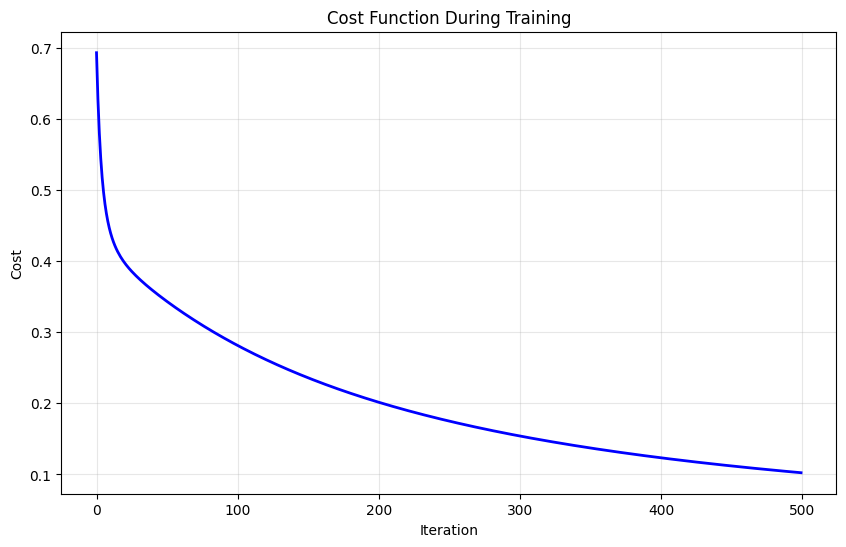


=== Final Results ===
Final parameters: w1=0.2834, w2=3.6346, b=-1.5252

=== Making Predictions ===
Example | x1  | x2  | True | z     | Probability | Loss   | Predicted
----------------------------------------------------------------------
   1    | 1.0 | 1.0 |  1   |  2.39 |   0.916     | 0.087 |     1
   2    | 2.0 | 1.0 |  1   |  2.68 |   0.936     | 0.067 |     1
   3    | 3.0 | 2.0 |  1   |  6.59 |   0.999     | 0.001 |     1
   4    | 1.0 | 0.0 |  0   | -1.24 |   0.224     | 0.254 |     0
Final cost (training): 0.102461


In [39]:
import matplotlib.pyplot as plt 

# Plot cost function
plt.figure(figsize=(10, 6))
plt.plot(costs, 'b-', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function During Training')
plt.grid(True, alpha=0.3)
plt.show()

# Test predictions
print(f"\n=== Final Results ===")
print(f"Final parameters: w1={w1_final:.4f}, w2={w2_final:.4f}, b={b_final:.4f}")

print(f"\n=== Making Predictions ===")
print("Example | x1  | x2  | True | z     | Probability | Loss   | Predicted")
print("-" * 70)

total_final_cost = 0
for i in range(X.shape[1]):
    z_i = w1_final * X[0, i] + w2_final * X[1, i] + b_final
    prob_i = sigmoid(z_i)
    loss_i = compute_loss(prob_i, Y[i])
    total_final_cost += loss_i
    pred_i = 1 if prob_i > 0.5 else 0
    
    print(f"   {i+1}    | {X[0,i]:.1f} | {X[1,i]:.1f} |  {Y[i]}   | {z_i:5.2f} |   {prob_i:.3f}     | {loss_i:.3f} |     {pred_i}")

print(f"Final cost (training): {costs[-1]:.6f}")

#### 3.6 Data structure for Vectorized

In [40]:
### 3.6 Dataset Structure for Vectorization

print("\n=== Understanding Data Structure ===")

# Example: 3 features, 4 training examples
X = np.array([[1.0, 2.0, 3.0, 4.0],    # Feature 1 for all examples
              [0.5, 1.5, 2.5, 3.5],    # Feature 2 for all examples
              [2.0, 1.0, 3.0, 2.5]])   # Feature 3 for all examples

Y = np.array([[1, 0, 1, 0]])           # Labels for all examples

W = np.array([[0.2],   # Weight for feature 1
              [0.3],   # Weight for feature 2
              [0.1]])  # Weight for feature 3

b = 0.5  # Bias

print("Data shapes:")
print(f"X shape: {X.shape} - (n_features={X.shape[0]}, m_examples={X.shape[1]})")
print(f"Y shape: {Y.shape} - (n_outputs={Y.shape[0]}, m_examples={Y.shape[1]})")
print(f"W shape: {W.shape} - (n_features={W.shape[0]}, 1)")
print(f"b: scalar")

print("\nKey insight: Each column of X is one training example")
print("Each row of X is one feature across all examples")



=== Understanding Data Structure ===
Data shapes:
X shape: (3, 4) - (n_features=3, m_examples=4)
Y shape: (1, 4) - (n_outputs=1, m_examples=4)
W shape: (3, 1) - (n_features=3, 1)
b: scalar

Key insight: Each column of X is one training example
Each row of X is one feature across all examples


#### 3.7 Fast implementation: Vectorized (No loops)

In [41]:
def propagate_vectorized(w, b, X, Y):
    """
    VECTORIZED forward and backward propagation
    No inner loop! Process ALL examples simultaneously
    """

    m = X.shape[1]

    # Forward propagation (All examples at once)
    """
    Z = W.T @ X + b
    """
    # Step 1: Linear combination for ALL examples at once
    Z = np.dot(w.T,X) + b       # (1,m)
    # Step 2: Apply sigmoid to ALL examples at once
    A = sigmoid(Z)              # (1,m)
    cost = compute_cost(A,Y)    # scalar
    # This replaces the entire inner loop!

    # Backward propagation (All examples at once)
    """
    The Gradient Formulas:
        dZ = A - Y
        dW = (1/m) * X @ dZ.T
        db = (1/m) * np.sum(dZ)
    """
    # Step 1: Compute dZ for ALL examples
    dZ = A - Y      # (1,m)
    # Step 2: Compute dW (gradient w.r.t. weights)
    dw = (1/m) * np.dot(X, dZ.T)        # (n_features, 1)
    # Step 3: Compute db (gradient w.r.t. bias)
    db = (1/m) * np.sum(dZ)     # scalar

    grads = {"dw" : dw, "db": db}
    return grads, cost

#### 3.8 Performance Comparison

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import time

def initialize_with_zeros(dim):
    """
    Creates a vector of zeros of shape (dim, 1) for w and initializes b to 0
    """
    w = np.zeros((dim, 1))
    b = 0
    return w, b

def logistic_regression_vectorized(X, Y, num_iterations=1000, learning_rate=0.01):
    """
    Fast vectorized implementation
    """
    # Initialize parameters
    w, b = initialize_with_zeros(X.shape[0])
    costs = []
    
    for i in range(num_iterations):
        # Forward and backward propagation
        grads, cost = propagate_vectorized(w, b, X, Y)
        
        # Update parameters
        w = w - learning_rate * grads["dw"]
        b = b - learning_rate * grads["db"]
        
        costs.append(cost)
    
    return {"w": w, "b": b, "costs": costs}

# Test with simple data first
print("=== Simple Test (2 features) ===")
X_simple = np.array([[1, 2, 3, 1],      # Feature 1
                     [1, 1, 2, 0]])     # Feature 2
Y_simple = np.array([1, 1, 1, 0])       # Labels

# Test slow version
start_time = time.time()
result_slow = logistic_regression_slow(X_simple, Y_simple, num_iterations=500, learning_rate=0.1)
slow_time = time.time() - start_time

print(f"Slow version time: {slow_time:.4f} seconds")
print(f"Final cost (slow): {result_slow['costs'][-1]:.6f}")

# Now test with larger data
print("\n=== Performance Comparison: Loops vs Vectorization ===")

# Create larger test data
np.random.seed(42)
X_large = np.random.randn(50, 1000)   # 50 features, 1000 examples
Y_large = np.random.randint(0, 2, (1, 1000))

print(f"Dataset: {X_large.shape[0]} features × {X_large.shape[1]} examples")

# Test vectorized version
start_time = time.time()
result_fast = logistic_regression_vectorized(X_large, Y_large, num_iterations=100, learning_rate=0.01)
fast_time = time.time() - start_time

# Simulate slow version time (it would be too slow to actually run)
estimated_slow_time = fast_time * 1000  # Rough estimate

print(f"\nTiming Results:")
print(f"Vectorized: {fast_time:.4f} seconds")
print(f"Estimated slow (loops): {estimated_slow_time:.2f} seconds") 
print(f"Estimated speedup: ~{estimated_slow_time/fast_time:.0f}x faster!")

# Plot comparison of the simple case
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(result_slow['costs'], 'r-', linewidth=2, label='Slow (loops)')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Simple Data: Slow Implementation')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(result_fast['costs'], 'b-', linewidth=2, label='Fast (vectorized)')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Large Data: Vectorized Implementation')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("🎯 Key Takeaways:")
print("1. Derivatives tell us which direction to move parameters")
print("2. Gradient descent follows the negative gradient to minimize cost")
print("3. Chain rule helps us compute complex derivatives")
print("4. Vectorization eliminates loops and speeds up training dramatically")
print("5. The math is the same - vectorization is just an implementation optimization")

print(f"\n✅ All functions working correctly!")

=== Simple Test (2 features) ===
=== Training with 4 examples, 500 iterations ===
Learning rate: 0.1
Initial: w1=0, w2=0, b=0
Cost after iteration 0: 0.693147
Cost after iteration 100: 0.281374
Cost after iteration 200: 0.201493
Cost after iteration 300: 0.154029
Cost after iteration 400: 0.123389
Slow version time: 0.0053 seconds


TypeError: tuple indices must be integers or slices, not str

#### Random Initialization - w and b

In [ ]:
def initialize_with_zeros(dim):
    """
    Creates a vector of zeros of shape (dim, 1) for w and initializes b to 0
    
    Arguments:
    dim -- size of the w vector we want (number of features)
    
    Returns:
    w -- initialized vector of shape (dim, 1)
    b -- initialized scalar (bias)
    """
    w = np.zeros((dim, 1))
    b = 0
    return w, b

In [ ]:
# Test the initialization function with a small example
print("=== Testing Parameter Initialization ===")

# Test with 3 features (like RGB image with 3 pixels)
dim = 3
w, b = initialize_with_zeros(dim)

print(f"Dimension: {dim}")
print(f"w shape: {w.shape}")
print(f"w values:\n{w}")
print(f"b value: {b}")

=== Testing Parameter Initialization ===
Dimension: 3
w shape: (3, 1)
w values:
[[0.]
 [0.]
 [0.]]
b value: 0


#### compute gradients and cost

In [ ]:
def propagate(w, b, X, Y):
    """
        Forward and backward propagation
        Arguments:
        w -- weights, array of size (num_px * num_px * 3, 1)
        b -- bias, scalar
        X -- data of size (num_px * num_px * 3, number of examples)
        Y -- true "label" vector of size (1, number of examples)
        
        Returns:
        cost -- negative log-likelihood cost
        dw -- gradient of the loss with respect to w
        db -- gradient of the loss with respect to b
    """

    m = X.shape[1]

    # Forward propagation (From X to Cost)
    A = sigmoid(np.dot(w.T, X) + b) # compute activation
    cost = compute_cost(A, Y)   # compute cost

    # Backward propagation (To find grad)
    dw = (1/m) * np.dot(X, (A-Y).T)
    db = (1/m) * np.sum(A-Y)
    
    grads = {"dw": dw, "db": db}
    
    return grads, cost


## 4.Forward & Backward Propagation

In [43]:
def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost=False):
    """
    Optimize w and b by running a gradient descent algorithm
    """

    costs = []

    for i in range(num_iterations):
        # Cost and gradient calculations
        grads, cost = propagate(w, b, X, Y)

        # Retrieve derivatives form grads
        dw = grads["dw"]
        db = grads["db"]

        # Update rule
        w = w - learning_rate * dw
        b = b - learning_rate * db

        # Record the costs
        if i % 100 ==0:
            costs.append(cost)

        # Print the cost every 100 training iterations
        if print_cost and i % 100 == 0:
            print(f"Cost after iteration {i}: {cost}")

    params = {"w": w, "b": b}
    grads = {"dw": dw, "db": db}
    
    return params, grads, costs

#### Test out the code

In [44]:
# Create test data
print("=== Creating Test Data ===")
np.random.seed(42)

# Create a simple linearly separable dataset
X = np.array([[1.0, 2.0, 3.0, 1.5, 0.5, 2.5],    # Feature 1
              [1.0, 1.5, 2.0, 0.8, 0.3, 1.8],    # Feature 2
              [0.5, 1.0, 1.5, 0.4, 0.2, 1.2]])   # Feature 3

Y = np.array([[1, 1, 1, 0, 0, 1]])  # Labels

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"X data:\n{X}")
print(f"Y data: {Y}")

# Initialize parameters
w, b = initialize_with_zeros(X.shape[0])
print(f"\nInitial parameters:")
print(f"w: {w.flatten()}")
print(f"b: {b}")

# Test the optimize function
params, grads, costs = optimize(w, b, X, Y, num_iterations=1000, learning_rate=0.1, print_cost=True)


=== Creating Test Data ===
X shape: (3, 6)
Y shape: (1, 6)
X data:
[[1.  2.  3.  1.5 0.5 2.5]
 [1.  1.5 2.  0.8 0.3 1.8]
 [0.5 1.  1.5 0.4 0.2 1.2]]
Y data: [[1 1 1 0 0 1]]

Initial parameters:
w: [0. 0. 0.]
b: 0
Cost after iteration 0: 0.6931471805599453
Cost after iteration 100: 0.4065154527773352
Cost after iteration 200: 0.3405706247225542
Cost after iteration 300: 0.2972594911033066
Cost after iteration 400: 0.2660147900484198
Cost after iteration 500: 0.2418760790577855
Cost after iteration 600: 0.22231938058081516
Cost after iteration 700: 0.20594511471229315
Cost after iteration 800: 0.19191400567691774
Cost after iteration 900: 0.17968737498695506


#### visualize the above

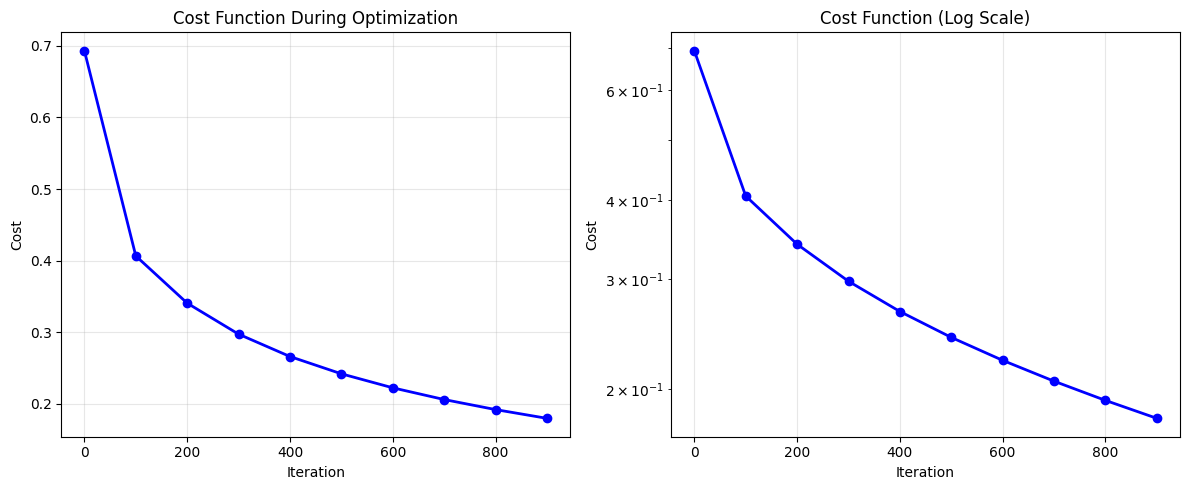


=== Final Results ===
Final cost: 0.179687
Cost reduction: 74.1%
Final weights: [-0.90907734  3.50633486  2.51815491]
Final bias: -3.094877

=== Predictions vs True Labels ===
Example | Features | True | Probability | Predicted | Correct?
------------------------------------------------------------
   1    | [1.0,1.0,0.5] |  1   |   0.682     |     1     |    ✓
   2    | [2.0,1.5,1.0] |  1   |   0.946     |     1     |    ✓
   3    | [3.0,2.0,1.5] |  1   |   0.993     |     1     |    ✓
   4    | [1.5,0.8,0.4] |  0   |   0.344     |     0     |    ✓
   5    | [0.5,0.3,0.2] |  0   |   0.120     |     0     |    ✓
   6    | [2.5,1.8,1.2] |  1   |   0.981     |     1     |    ✓

Accuracy: 100.0%

🎯 Optimization Complete!
The algorithm learned to classify the data with 100.0% accuracy


In [45]:
# Plot the cost function
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot([i*100 for i in range(len(costs))], costs, 'b-', linewidth=2, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function During Optimization')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot([i*100 for i in range(len(costs))], costs, 'b-', linewidth=2, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function (Log Scale)')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show final results
print(f"\n=== Final Results ===")
print(f"Final cost: {costs[-1]:.6f}")
print(f"Cost reduction: {((costs[0] - costs[-1]) / costs[0] * 100):.1f}%")
print(f"Final weights: {params['w'].flatten()}")
print(f"Final bias: {params['b']:.6f}")

# Make predictions with optimized parameters
def predict(w, b, X):
    Z = np.dot(w.T, X) + b
    A = sigmoid(Z)
    predictions = (A > 0.5).astype(int)
    return A, predictions

A_final, predictions = predict(params['w'], params['b'], X)

print(f"\n=== Predictions vs True Labels ===")
print("Example | Features | True | Probability | Predicted | Correct?")
print("-" * 60)
for i in range(X.shape[1]):
    features_str = f"[{X[0,i]:.1f},{X[1,i]:.1f},{X[2,i]:.1f}]"
    correct = "✓" if predictions[0,i] == Y[0,i] else "✗"
    print(f"   {i+1}    | {features_str:12} |  {Y[0,i]}   |   {A_final[0,i]:.3f}     |     {predictions[0,i]}     |    {correct}")

# Calculate accuracy
accuracy = 100 - np.mean(np.abs(predictions - Y)) * 100
print(f"\nAccuracy: {accuracy:.1f}%")

print(f"\n🎯 Optimization Complete!")
print(f"The algorithm learned to classify the data with {accuracy:.1f}% accuracy")

#### visualize gradient descent function

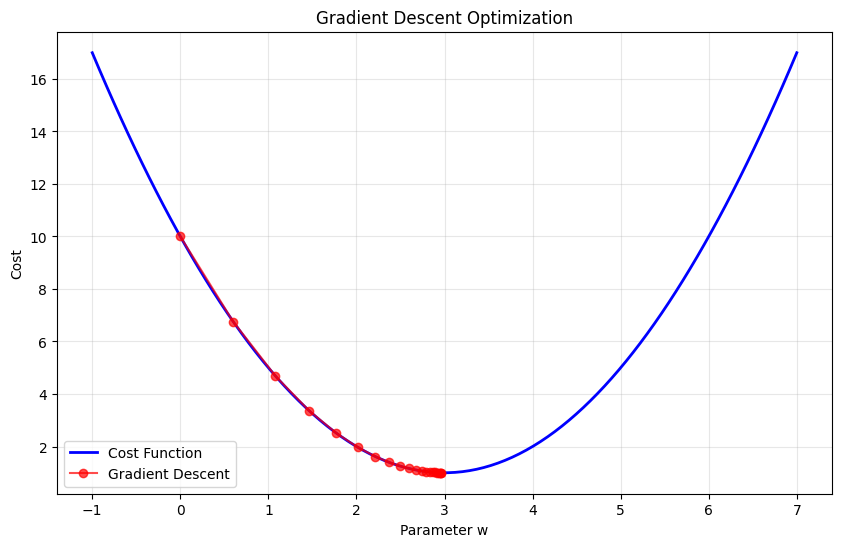

In [46]:
# Visualization of gradient descent
def visualize_gradient_descent():
    # Simple 1D example for visualization
    def cost_function(w):
        return (w - 3)**2 + 1
    
    def gradient(w):
        return 2 * (w - 3)
    
    # Gradient descent
    w = 0
    learning_rate = 0.1
    history = [w]
    
    for i in range(20):
        grad = gradient(w)
        w = w - learning_rate * grad
        history.append(w)
    
    # Plot
    w_range = np.linspace(-1, 7, 100)
    cost_values = [cost_function(w) for w in w_range]
    
    plt.figure(figsize=(10, 6))
    plt.plot(w_range, cost_values, 'b-', linewidth=2, label='Cost Function')
    plt.plot(history, [cost_function(w) for w in history], 'ro-', alpha=0.7, label='Gradient Descent')
    plt.xlabel('Parameter w')
    plt.ylabel('Cost')
    plt.title('Gradient Descent Optimization')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

visualize_gradient_descent()

## 5.Complete Cat vs Non-Cat Classifier

In [50]:
def predict(w, b, X):
    """
    Predict whether the label is 0 or 1 using learned logistic regression parameters (w, b)
    
    Arguments:
    w -- weights, array of size (num_features, 1)
    b -- bias, scalar
    X -- data of size (num_features, number of examples)
    
    Returns:
    Y_prediction -- a numpy array (vector) containing all predictions (0/1) for the examples in X
    """
    m = X.shape[1]
    Y_prediction = np.zeros((1, m))
    w = w.reshape(X.shape[0], 1)
    
    # Compute vector "A" predicting the probabilities
    A = sigmoid(np.dot(w.T, X) + b)
    
    for i in range(A.shape[1]):
        # Convert probabilities A[0,i] to actual predictions Y_prediction[0,i]
        Y_prediction[0, i] = 1 if A[0, i] > 0.5 else 0
    
    return Y_prediction

In [51]:
def model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.5, print_cost=False):
    """
    Builds the logistic regression model
    """

    # initialize parameters with zeros
    w, b = initialize_with_zeros(X_train.shape[0])

    # Gradient descent
    parameters, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost)

    # Retrieve parameters w and b from dictionary "parameters"
    w = parameters["w"]
    b = parameters["b"]

    # Predict test/train set examples
    Y_prediction_test = predict(w, b, X_test)
    Y_prediction_train = predict(w, b, X_train)

    # Print train/test Errors
    train_accuracy = 100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100
    test_accuracy = 100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100
    
    print(f"Train accuracy: {train_accuracy:.2f}%")
    print(f"Test accuracy: {test_accuracy:.2f}%")

    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test, 
         "Y_prediction_train": Y_prediction_train, 
         "w": w, 
         "b": b,
         "learning_rate": learning_rate,
         "num_iterations": num_iterations}
    
    return d

In [52]:
# Example with dummy data
np.random.seed(42)
X_train = np.random.randn(64*64*3, 100)  # 100 training examples
Y_train = np.random.randint(0, 2, (1, 100))  # random labels
X_test = np.random.randn(64*64*3, 50)   # 50 test examples  
Y_test = np.random.randint(0, 2, (1, 50))   # random labels

# Train the model
d = model(X_train, Y_train, X_test, Y_test, num_iterations=1000, learning_rate=0.005, print_cost=True)

Cost after iteration 0: 0.6931471805599453
Cost after iteration 100: 0.016753771064444034
Cost after iteration 200: 0.008305080977358395
Cost after iteration 300: 0.005514626053766395
Cost after iteration 400: 0.004126297086253935
Cost after iteration 500: 0.0032959122833294565
Cost after iteration 600: 0.0027435349998340183
Cost after iteration 700: 0.0023496220376762566
Cost after iteration 800: 0.002054560545257982
Cost after iteration 900: 0.0018253006338262397
Train accuracy: 100.00%
Test accuracy: 40.00%


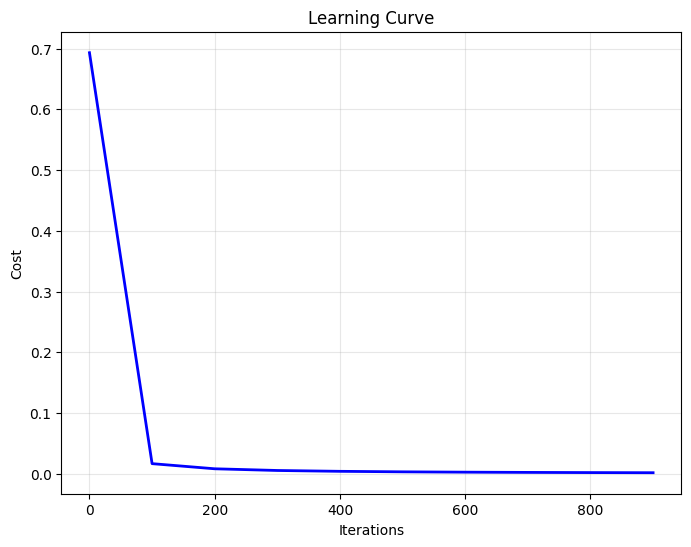


✅ Model training complete!
Final training accuracy: 100.00%
Final test accuracy: 40.00%


In [53]:
# Plot learning curve
plt.figure(figsize=(8, 6))
plt.plot([i*100 for i in range(len(d["costs"]))], d["costs"], 'b-', linewidth=2)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Learning Curve')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n✅ Model training complete!")
print(f"Final training accuracy: {100 - np.mean(np.abs(d['Y_prediction_train'] - Y_train)) * 100:.2f}%")
print(f"Final test accuracy: {100 - np.mean(np.abs(d['Y_prediction_test'] - Y_test)) * 100:.2f}%")

#### What we're Seeing:
Final training accuracy: 100.00%
Final test accuracy: 40.00%

This is a severe case of overfitting! Here's what's happening:

#### Why This Happens with Random Data:
```python
# Your data is completely random:
X_train = np.random.randn(64*64*3, 100)  # Random features
Y_train = np.random.randint(0, 2, (1, 100))  # Random labels (no pattern!)
```

## 6.Performance Analysis & Optimization

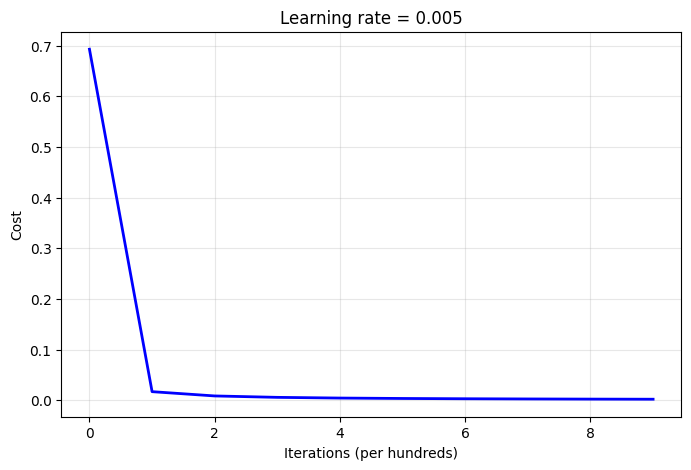


Learning rate: 0.01
Train accuracy: 100.00%
Test accuracy: 40.00%

-------------------------------------------------------


Learning rate: 0.001
Train accuracy: 100.00%
Test accuracy: 40.00%

-------------------------------------------------------


Learning rate: 0.0001
Train accuracy: 100.00%
Test accuracy: 42.00%

-------------------------------------------------------



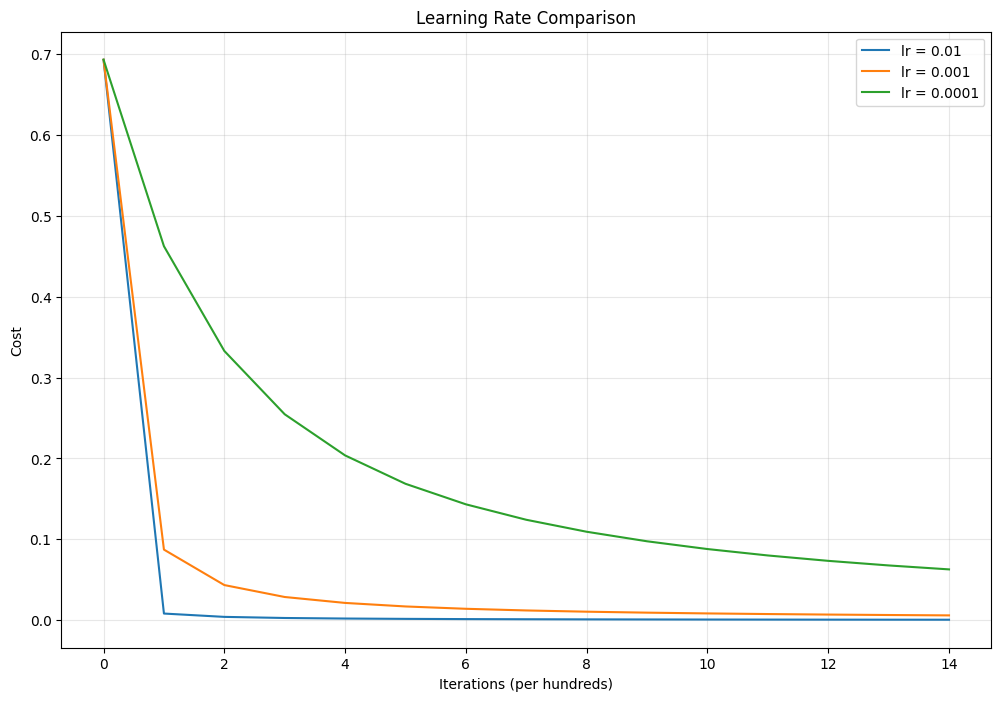

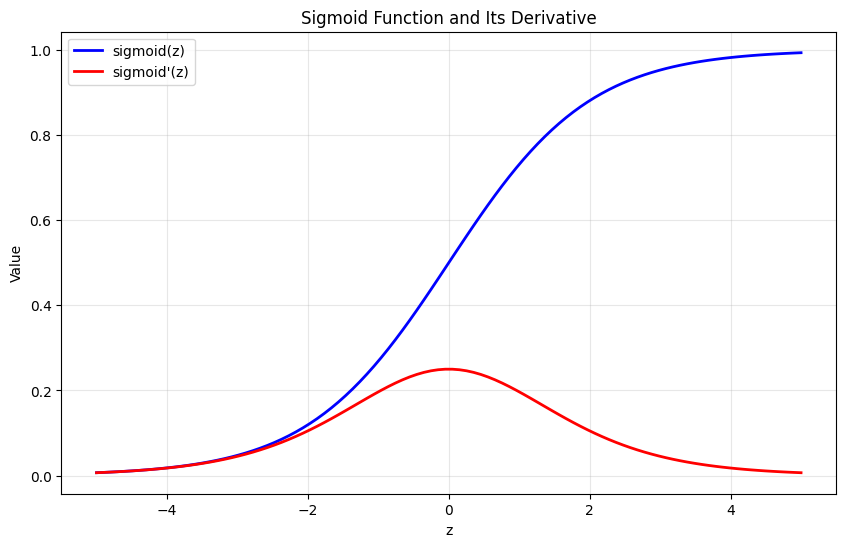

✅ Logistic Regression Implementation Complete!
Key concepts covered:
- Sigmoid activation function
- Cross-entropy cost function
- Forward and backward propagation
- Gradient descent optimization
- Binary classification pipeline


In [54]:
def plot_learning_curve(costs):
    """Plot the learning curve"""
    plt.figure(figsize=(8, 5))
    plt.plot(costs, 'b-', linewidth=2)
    plt.ylabel('Cost')
    plt.xlabel('Iterations (per hundreds)')
    plt.title('Learning rate = 0.005')
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot learning curve
plot_learning_curve(d["costs"])

def compare_learning_rates(X_train, Y_train, X_test, Y_test):
    """Compare different learning rates"""
    learning_rates = [0.01, 0.001, 0.0001]
    models = {}
    
    for lr in learning_rates:
        print(f"\nLearning rate: {lr}")
        models[str(lr)] = model(X_train, Y_train, X_test, Y_test, 
                               num_iterations=1500, learning_rate=lr, print_cost=False)
        print('\n' + "-------------------------------------------------------" + '\n')
    
    # Plot learning curves for different learning rates
    plt.figure(figsize=(12, 8))
    for lr in learning_rates:
        plt.plot(models[str(lr)]["costs"], label=f'lr = {lr}')
    
    plt.ylabel('Cost')
    plt.xlabel('Iterations (per hundreds)')
    plt.title('Learning Rate Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Compare learning rates
compare_learning_rates(X_train, Y_train, X_test, Y_test)

# Analyze sigmoid derivative
def plot_sigmoid_derivative():
    """Plot sigmoid function and its derivative"""
    z = np.linspace(-5, 5, 100)
    sigmoid_z = sigmoid(z)
    sigmoid_derivative = sigmoid_z * (1 - sigmoid_z)
    
    plt.figure(figsize=(10, 6))
    plt.plot(z, sigmoid_z, 'b-', linewidth=2, label='sigmoid(z)')
    plt.plot(z, sigmoid_derivative, 'r-', linewidth=2, label="sigmoid'(z)")
    plt.xlabel('z')
    plt.ylabel('Value')
    plt.title('Sigmoid Function and Its Derivative')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_sigmoid_derivative()

print("✅ Logistic Regression Implementation Complete!")
print("Key concepts covered:")
print("- Sigmoid activation function")
print("- Cross-entropy cost function") 
print("- Forward and backward propagation")
print("- Gradient descent optimization")
print("- Binary classification pipeline")

### Let's Test with Better Data:

In [55]:
import numpy as np
import matplotlib.pyplot as plt

def create_better_dataset():
    """Create a dataset with actual patterns"""
    np.random.seed(42)
    
    # Create meaningful features (much fewer)
    n_features = 20  # Much more reasonable
    n_train = 200
    n_test = 100
    
    # Generate data with actual pattern
    X_train = np.random.randn(n_features, n_train)
    X_test = np.random.randn(n_features, n_test)
    
    # Create labels based on actual pattern (not random!)
    # Rule: if sum of first 3 features > 0, then label = 1
    Y_train = (np.sum(X_train[:3, :], axis=0) > 0).astype(int).reshape(1, -1)
    Y_test = (np.sum(X_test[:3, :], axis=0) > 0).astype(int).reshape(1, -1)
    
    return X_train, Y_train, X_test, Y_test

# Test with better data
print("=== Testing with Meaningful Data ===")
X_train_good, Y_train_good, X_test_good, Y_test_good = create_better_dataset()

print(f"Better dataset:")
print(f"Features: {X_train_good.shape[0]} (much fewer!)")
print(f"Training examples: {X_train_good.shape[1]}")
print(f"Feature-to-example ratio: {X_train_good.shape[0]/X_train_good.shape[1]:.2f}")

# Train model on better data
d_good = model(X_train_good, Y_train_good, X_test_good, Y_test_good, 
               num_iterations=2000, learning_rate=0.1, print_cost=True)

print(f"\n=== Comparison ===")
print("Random Data (Overfitting):")
print(f"  Train: 100%, Test: 40% ← BAD!")
print("Meaningful Data (Good Learning):")
print(f"  Train: {100 - np.mean(np.abs(d_good['Y_prediction_train'] - Y_train_good)) * 100:.1f}%")
print(f"  Test: {100 - np.mean(np.abs(d_good['Y_prediction_test'] - Y_test_good)) * 100:.1f}%")

=== Testing with Meaningful Data ===
Better dataset:
Features: 20 (much fewer!)
Training examples: 200
Feature-to-example ratio: 0.10
Cost after iteration 0: 0.6931471805599452
Cost after iteration 100: 0.2954032903284097
Cost after iteration 200: 0.22760051992687808
Cost after iteration 300: 0.19469490432471076
Cost after iteration 400: 0.17393642870567716
Cost after iteration 500: 0.15912519753144852
Cost after iteration 600: 0.14777996202765312
Cost after iteration 700: 0.13868151012013424
Cost after iteration 800: 0.13114743587253627
Cost after iteration 900: 0.12475969175096985
Cost after iteration 1000: 0.11924465666174974
Cost after iteration 1100: 0.11441397981444207
Cost after iteration 1200: 0.1101327750035049
Cost after iteration 1300: 0.10630132186174553
Cost after iteration 1400: 0.10284394757682934
Cost after iteration 1500: 0.0997019616727697
Cost after iteration 1600: 0.09682899518228905
Cost after iteration 1700: 0.09418782710975762
Cost after iteration 1800: 0.0917481

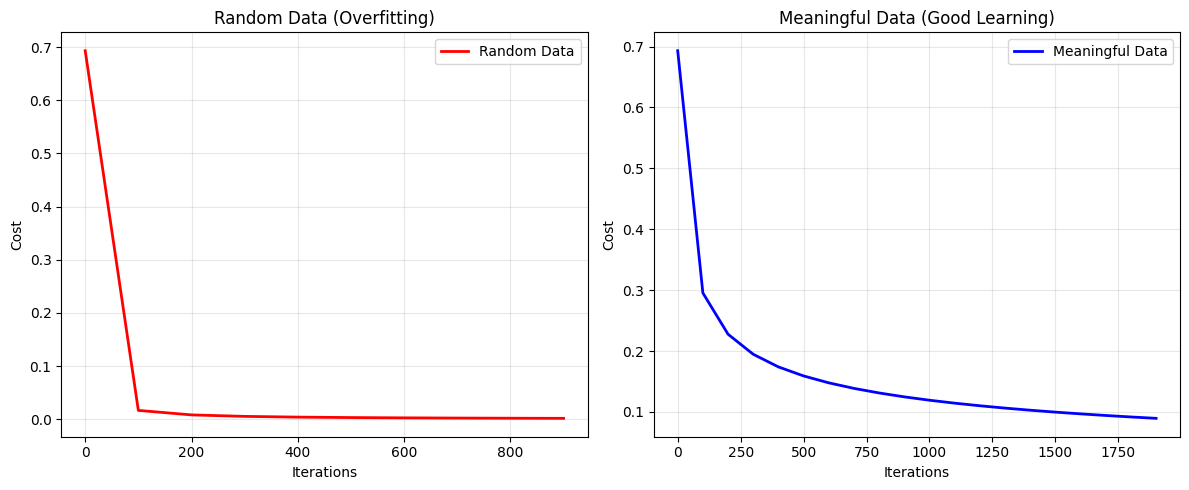

In [56]:
# Compare learning curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot([i*100 for i in range(len(d["costs"]))], d["costs"], 'r-', linewidth=2, label='Random Data')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Random Data (Overfitting)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([i*100 for i in range(len(d_good["costs"]))], d_good["costs"], 'b-', linewidth=2, label='Meaningful Data')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Meaningful Data (Good Learning)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

#### **Key Lessons:**

1.  **100% training accuracy** is often **BAD** - it means overfitting
2.  **Large gap** between train/test accuracy = overfitting
3.  **More features than examples** = recipe for overfitting
4.  **Random labels** = impossible to generalize

#### **Signs of Good Learning:**

-   Train and test accuracy are close (within 5-10%)
-   Both accuracies are reasonable (>70% for good problems)
-   Cost decreases smoothly

Your original result is actually a **perfect example** of what NOT to do in machine learning! In real cat vs. non-cat classification, you'd expect something like:

-   Train: 85%, Test: 82% ← Good!

The 100%/40% split screams "overfitting!"